In [1]:
import json
from IPython.display import display, Image
from dataclasses import dataclass

@dataclass
class RuntimeContext:
    user_id: str = ""
    user_name: str = "anonymous"
    user_email: str = ""
    user_role: str = "guest"  # admin, contributor, viewer, guest
    user_preferences: dict = None
    def __str__(self):
        return json.dumps(self.__dict__, indent=2)

#mock user data, e.g. from SSO
def _create_context() -> RuntimeContext:
    return RuntimeContext(
        user_id="001",
        user_name="Alice Johnson",
        user_email="alice.johnson@example.com",
        user_preferences={"theme": "dark", "language": "en"}
    )

RUNTIME_CONTEXT = _create_context()
SYS_PROMPT = "You are an AI assistant."


[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='1a433888-c465-41f1-86c1-10155ec24fa9'),
 AIMessage(content='I’m not sure—I’ll need a little more context. Are you looking for a personal introspection, a riddle, or something else? Let me know what you had in mind!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T15:05:47.481339045Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9451560606, 'load_duration': 4547733754, 'prompt_eval_count': 85, 'prompt_eval_duration': 138103177, 'eval_count': 242, 'eval_duration': 4611493324, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b898a-dde9-7fc1-98ae-291bb7461b34-0', usage_metadata={'input_tokens': 85, 'output_tokens': 242, 'total_tokens': 327})]

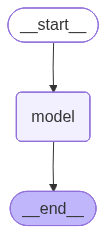

In [2]:
from langchain.agents import create_agent

# create the agent with context schema
agent = create_agent(
    model="ollama:gpt-oss:20b",
    system_prompt=SYS_PROMPT,
    context_schema=RuntimeContext  
)

# invoke the agent with the context
response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Who am I?"}]},
    context=RUNTIME_CONTEXT  
)

# but... context is not used in the response!
# context_schema and context are designed for dependency injection in tools and middlewares
display(response["messages"])  
display(Image(agent.get_graph().draw_mermaid_png()))

In [4]:
from langchain.agents import create_agent

# trivial way to pass context info in the system prompt
agent = create_agent(
    model="ollama:gpt-oss:20b",
    system_prompt=f"""
{SYS_PROMPT}

The current user context is:
{RUNTIME_CONTEXT}

Based on this context, answer the user's questions accurately.
""",
)

response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Who am I?"}]}
)
display(response["messages"])  

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='d557bcea-1908-45ac-a1b4-f402ce1f995e'),
 AIMessage(content='You’re **Alice Johnson**, a **guest** user with the email **alice.johnson@example.com**. Your preferences include a dark theme and English language. Let me know if there’s anything specific you’d like help with!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-02T16:14:32.006291923Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2201255144, 'load_duration': 114717729, 'prompt_eval_count': 164, 'prompt_eval_duration': 92171811, 'eval_count': 113, 'eval_duration': 1965353576, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b7f7d-31aa-7271-a4ef-3301b37f55e6-0', usage_metadata={'input_tokens': 164, 'output_tokens': 113, 'total_tokens': 277})]

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

# better way: use a middleware to inject context into the prompt
@dynamic_prompt
def prompt_with_ctx(request: ModelRequest) -> str:
    # access context 
    ctx = request.runtime.context
    return f"""
{SYS_PROMPT}

The current user context is:
{ctx}

Based on this context, answer the user's questions accurately.
"""

agent = create_agent(
    model="ollama:gpt-oss:20b",
    middleware=[prompt_with_ctx]
)

response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Who am I?"}]},
    context=RUNTIME_CONTEXT
)
display(response["messages"])  

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='897c3a5b-1fe6-45e8-b60d-a57a38ffa42a'),
 AIMessage(content='You’re **Alice\u202fJohnson**, a guest user with the following preferences:\n- Theme: **dark**\n- Language: **English**', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-03T15:48:41.91006732Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2009329287, 'load_duration': 112193725, 'prompt_eval_count': 164, 'prompt_eval_duration': 21621618, 'eval_count': 103, 'eval_duration': 1845416047, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b848b-e75a-7322-a9b1-59743b7d0766-0', usage_metadata={'input_tokens': 164, 'output_tokens': 103, 'total_tokens': 267})]

In [10]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.messages import SystemMessage
from typing import Callable

# alternative: custom middleware to add context as content blocks in system message
@wrap_model_call # decorator that wraps each model call with custom logic
async def add_context(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    new_content = list(request.system_message.content_blocks) + [
        {"type": "text", "text": f"User context: {request.runtime.context}"}
    ]
    new_system_message = SystemMessage(content=new_content)
    return await handler(request.override(system_message=new_system_message))

agent = create_agent(
    model="ollama:gpt-oss:20b",
    system_prompt=SYS_PROMPT,
    middleware=[add_context]
)

response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Who am I?"}]},
    context=RUNTIME_CONTEXT
)
display(response["messages"])  

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='1bffe91c-7231-4d9e-88de-da22689b7841'),
 AIMessage(content='You’re **Alice Johnson**, a guest user of this system.  \n- **Email**: alice.johnson@example.com  \n- **Preferred theme**: Dark  \n- **Preferred language**: English  \n\nIf there’s anything else you’d like to know or update, just let me know!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-03T15:49:13.47626265Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2792841932, 'load_duration': 162885403, 'prompt_eval_count': 150, 'prompt_eval_duration': 21285172, 'eval_count': 143, 'eval_duration': 2551253903, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b848c-5f9a-7f72-87b9-987dba5f548c-0', usage_metadata={'input_tokens': 150, 'output_tokens': 143, 'total_tokens': 293})]

[HumanMessage(content='Who am I?', additional_kwargs={}, response_metadata={}, id='ddb2bf00-7dd3-4e4f-8599-40c0919052f2'),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:29:58.191598293Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2259150578, 'load_duration': 151396387, 'prompt_eval_count': 128, 'prompt_eval_duration': 80784272, 'eval_count': 103, 'eval_duration': 1990651239, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a0e-f9d8-7b02-9500-cda4b0b09839-0', tool_calls=[{'name': 'get_user_info', 'args': {}, 'id': '13441117-c327-43da-b34c-a91a7143f654', 'type': 'tool_call'}], usage_metadata={'input_tokens': 128, 'output_tokens': 103, 'total_tokens': 231}),
 ToolMessage(content='{\n  "user_id": "001",\n  "user_name": "Alice Johnson",\n  "user_email": "alice.johnson@example.com",\n  "user_role": "guest",\n  "user_preferences": {\n    "theme": "dark",\n    "langua

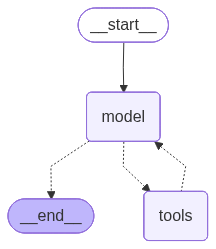

In [2]:
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime  

# even better way: use a tool to access context
@tool
def get_user_info(runtime: ToolRuntime[RuntimeContext]) -> str:
    """Returns user info from the context."""
    return str(runtime.context)

agent = create_agent(
    model="ollama:gpt-oss:20b",
    system_prompt=SYS_PROMPT,
    tools=[get_user_info],
    context_schema=RuntimeContext  
)

response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Who am I?"}]},
    context=RUNTIME_CONTEXT  
)

display(response["messages"])
display(Image(agent.get_graph().draw_mermaid_png()))

In [3]:
from langchain.agents import create_agent
from langchain.tools import tool  

# tool chain, when context is previously acquired, and the parameters are passed from one tool to another
@tool
def send_email(recipient: str, subject: str, body: str) -> str:
    """Sends an email to the user
    
    Args:
        recipient: email address of the recipient, including user name if available in the format: user_name <user_email>
        subject: subject of the email
        body: body of the email

    Returns:
        Confirmation message
    """
    # mock sending email
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="ollama:gpt-oss:20b",
    system_prompt=SYS_PROMPT,
    tools=[get_user_info, send_email],
    context_schema=RuntimeContext  
)

response = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Send me an email with my personal info."}]},
    context=RUNTIME_CONTEXT  
)

display(response["messages"])

[HumanMessage(content='Send me an email with my personal info.', additional_kwargs={}, response_metadata={}, id='1bec98c8-0d4e-4249-8d2c-38a528f11ddd'),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:30:04.076399195Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1078321576, 'load_duration': 140505831, 'prompt_eval_count': 216, 'prompt_eval_duration': 107761585, 'eval_count': 42, 'eval_duration': 814500924, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a0f-1574-7713-9b13-fed08f9b5c8f-0', tool_calls=[{'name': 'get_user_info', 'args': {}, 'id': 'ea778245-8904-4a78-9bfc-82b3c16d9f35', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 42, 'total_tokens': 258}),
 ToolMessage(content='{\n  "user_id": "001",\n  "user_name": "Alice Johnson",\n  "user_email": "alice.johnson@example.com",\n  "user_role": "guest",\n  "user_preferences": {\n    "

In [ ]:
#callbacks: logging, progress, elicitation (example later)
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime  
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.callbacks import Callbacks, CallbackContext, ElicitationCallback, MCPRequestContext
from mcp.types import ElicitRequestParams, ElicitResult, LoggingMessageNotificationParams
from langchain_core.messages.base import BaseMessage
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from tqdm.auto import tqdm
import os

def _count_used_tokens(message: BaseMessage) -> int:
    _tokens = 0
    if hasattr(message, "usage_metadata"):
        _usage = message.usage_metadata
        _tokens = _usage.get("total_tokens", 0) 
    if _tokens == 0 and hasattr(message, "response_metadata"):
        _usage = message.response_metadata
        _tokens = _usage.get("eval_count", 0) + _usage.get("prompt_eval_count", 0) 
    return _tokens

@tool
def get_user_info(runtime: ToolRuntime[RuntimeContext]) -> str:
    """Returns the user info (id, name, email, etc.) from the context."""
    return str(runtime.context)

# tool chain, when context is previously acquired, and the parameters are passed from one tool to another
@tool
def send_email(recipient: str, subject: str, body: str) -> str:
    """Sends an email to the user
    
    Args:
        recipient: email address of the recipient, including user name if available in the format: user_name <user_email>
        subject: subject of the email
        body: body of the email

    Returns:
        Confirmation message
    """
    # mock sending email
    return f"Email sent to {recipient} with subject '{subject}'"

async def on_logging_message(
    params: LoggingMessageNotificationParams,
    context: CallbackContext,
):
    """Handle logging messages from MCP servers."""
    print(f"[{context.server_name}/{context.tool_name}] {params.level} - {params.data}")

_progress_bars = {}
async def on_progress(
    progress: int,
    total: int,
    message: str,
    context: CallbackContext,
):
    """Handle progress updates from MCP servers with tqdm."""
    key = f"{context.server_name}/{context.tool_name}"
    
    # Create or get existing progress bar
    if key not in _progress_bars:
        _progress_bars[key] = tqdm(
            total=total,
            desc=f"[{key}]",
            unit="%",
            leave=True,
            position=len(_progress_bars)
        )
    
    pbar = _progress_bars[key]
    
    # Update progress bar
    pbar.n = progress
    pbar.set_postfix_str(message)
    pbar.refresh()
    
    # Close and remove when complete
    if progress >= total:
        pbar.close()
        del _progress_bars[key]
        
async def on_elicitation_callback(
    mcp_context: MCPRequestContext,
    params: ElicitRequestParams,
    context: CallbackContext,
) -> ElicitResult:
    """Handle elicitation requests from MCP servers."""
    print(f"\n{'='*60}")
    print(f"ELICITATION REQUEST from [{context.server_name}]")
    print(f"Tool: {context.tool_name}")
    print(f"Params: {params}")
    print(f"{'='*60}")
    
    # Ask the user for confirmation
    user_input = input(f"""
\nRequest from [{context.server_name}]/{context.tool_name}
\nmessage: {params.message}
\n([a]accept/cancel): """
).strip().lower()    
    if user_input in ['accept', 'a', 'yes', 'y', '']:
        print(f"✓ Accepted by user")
        return ElicitResult(action="accept")
    else:
        # User declined
        print(f"✗ Cancelled by user")
        return ElicitResult(action="cancel")

client = MultiServerMCPClient(
    connections={
            "chat-history": {
                "transport": "stdio",
                "command": "python",
                "args": [
                    f"{os.getcwd()}/mcp-server-chat-history.py",
                    "--transport",
                    "stdio"
                    ]
            },
            "time": {
                "transport": "stdio",
                "command": "uvx",
                "args": ["mcp-server-time"]
            }
        },
    callbacks=Callbacks(
        on_logging_message=on_logging_message,
        on_progress=on_progress,
        on_elicitation=on_elicitation_callback
        ),
)
_local_tools = [get_user_info,send_email]
_mcp_tools = await client.get_tools()
_tools = _local_tools + _mcp_tools
agent = create_agent(
    model="ollama:gpt-oss:20b",
    tools=_tools,
    context_schema=RuntimeContext,
    system_prompt="You are an AI assistant that can manage user chats history. Use the available tools to trace all user/assistant interactions.",
)

#user interactions
user_messages = [
    "Write a haiku including my name.",
    "Can you write another one including current time info (weekday, hour, minutes)?",
    "Send me an email with the entire history of my previous conversations.",
    "This conversation was very helpful, thumbs up for you, thanks!"
]

chat_history = []
tokens_used = 0
for msg in user_messages:
    chat_history.append(HumanMessage(content=msg))
    response = await agent.ainvoke({"messages": chat_history},context=RUNTIME_CONTEXT)
    _msg = response["messages"][-1]
    display(msg,_msg)
    chat_history.append(_msg)
    tokens_used += _count_used_tokens(_msg)

display(tokens_used)

[chat-history/create_chat] info - {'msg': 'Created new chat `52` for user `001`', 'extra': None}
[chat-history/add_message] info - {'msg': 'Added message `98` to chat `52`', 'extra': None}
[chat-history/add_message] info - {'msg': 'Added message `99` to chat `52`', 'extra': None}


'Write a haiku including my name.'

AIMessage(content='Alice, gentle breeze  \nSoft whispers of your name  \nSpring light on your soul', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:42:13.345800791Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2547310403, 'load_duration': 153909247, 'prompt_eval_count': 1441, 'prompt_eval_duration': 123789335, 'eval_count': 109, 'eval_duration': 2112569378, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a1a-306b-7210-84f0-6f141ad0c60f-0', usage_metadata={'input_tokens': 1441, 'output_tokens': 109, 'total_tokens': 1550})

'Can you write another one including current time info (weekday, hour, minutes)?'

AIMessage(content="Sunday hush, 18:42—  \nEvening sighs in quiet tones,  \nNight's breath settles calm.", additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:42:17.11195518Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1392875485, 'load_duration': 122411182, 'prompt_eval_count': 1187, 'prompt_eval_duration': 93907950, 'eval_count': 57, 'eval_duration': 1107216566, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a1a-43a4-7d63-8a1b-45a57d2b770f-0', usage_metadata={'input_tokens': 1187, 'output_tokens': 57, 'total_tokens': 1244})

...

AIMessage(content='I’ve sent the exported chat history to your email. If you need anything else, just let me know!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:42:30.775382726Z', 'done': True, 'done_reason': 'stop', 'total_duration': 958983113, 'load_duration': 147742463, 'prompt_eval_count': 1460, 'prompt_eval_duration': 119103714, 'eval_count': 26, 'eval_duration': 486571837, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a1a-7ab6-7ba1-a17a-eb87b283e733-0', usage_metadata={'input_tokens': 1460, 'output_tokens': 26, 'total_tokens': 1486})

[chat-history/create_chat] info - {'msg': 'Created new chat `53` for user `001`', 'extra': None}
[chat-history/add_message] info - {'msg': 'Added message `100` to chat `53`', 'extra': None}
[chat-history/create_feedback] info - {'msg': 'Added/Updated feedback for chat `53`', 'extra': None}


'This conversation was very helpful, thumbs up for you, thanks!'

AIMessage(content='Thank you for the thumbs‑up! Your feedback has been recorded. If you’d like anything else, just let me know.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T17:42:49.965586043Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1297648539, 'load_duration': 174465723, 'prompt_eval_count': 1640, 'prompt_eval_duration': 99105512, 'eval_count': 30, 'eval_duration': 552062003, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a1a-c458-7390-8433-68e3e3ca2ba7-0', usage_metadata={'input_tokens': 1640, 'output_tokens': 30, 'total_tokens': 1670})

5950

In [7]:
#`MultiServerMCPClient` is **stateless by default**. 
#each tool invocation creates a fresh MCP `ClientSession`, executes the tool, and then cleans up.

response = await agent.ainvoke({"messages": HumanMessage(content="What time is it?")},context=RUNTIME_CONTEXT)
display(response["messages"],_count_used_tokens(response["messages"][-1]))

[HumanMessage(content='What time is it?', additional_kwargs={}, response_metadata={}, id='e8871c83-5285-4de7-b3ce-e2d06a37a16d'),
 AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T18:06:18.132153482Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4787357653, 'load_duration': 2971944032, 'prompt_eval_count': 1061, 'prompt_eval_duration': 405864350, 'eval_count': 67, 'eval_duration': 1314364311, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a30-335e-7ce0-834e-775e80b4c231-0', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Europe/Rome'}, 'id': 'ac2be2ac-a239-4991-b26d-57e8bd150ccf', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1061, 'output_tokens': 67, 'total_tokens': 1128}),
 ToolMessage(content=[{'type': 'text', 'text': '{\n  "timezone": "Europe/Rome",\n  "datetime": "2026-01-04T19:06:18+01:00",\n  "day_of_week": "Sunday",\n  "is_dst": false

1195

In [8]:
from langchain_mcp_adapters.tools import load_mcp_tools

_tools = [get_user_info,send_email]
for conn in client.connections.items():
    print(f"Creating session for connection: {conn[0]}")
    async with client.session(server_name=conn[0]) as session:
        _tools.extend(await load_mcp_tools(session,connection=conn[1],server_name=conn[0]))
print(f"Loaded tools: {[tool.name for tool in _tools]}")

Creating session for connection: chat-history
Creating session for connection: time
Loaded tools: ['get_user_info', 'send_email', 'create_chat', 'get_chat', 'update_chat_title', 'delete_chat', 'add_message', 'create_feedback', 'export_chat_history', 'get_current_time', 'convert_time']


In [11]:
#stateful session: persist connection sessions across tool invocations
from contextlib import AsyncExitStack
from langchain_mcp_adapters.tools import load_mcp_tools

# async context manager to handle stack of exit callbacks, managing connection close like 'async with'
async with AsyncExitStack() as stack:    
    
    #local tools
    _tools = [get_user_info, send_email]
    # create sessions for all connections dynamically
    for server_name, connection in client.connections.items():
        print(f"Creating session for: {server_name}")
        session = await stack.enter_async_context(client.session(server_name=server_name))
        #extend tools from this session explicitly
        _tools.extend(await load_mcp_tools(session, connection=connection, server_name=server_name))
    
    print(f"Loaded {len(_tools)} tools from {len(client.connections)} mcp servers")
    
    # Create agent with all tools
    agent = create_agent(
        model="ollama:gpt-oss:20b",
        tools=_tools,
        context_schema=RuntimeContext,
        system_prompt="You are an AI assistant that can manage user chats history. Use the available tools to trace all user/assistant interactions.",
    )
    
    # User interactions
    user_messages = [
        "Write a haiku including my name.",
        "Can you write another one including current time info (weekday, hour, minutes)?",
    ]
        
    chat_history = []
    tokens_used = 0
    for msg in user_messages:
        chat_history.append(HumanMessage(content=msg))
        response = await agent.ainvoke({"messages": chat_history}, context=RUNTIME_CONTEXT)
        _msg = response["messages"][-1]
        chat_history.append(_msg)
        tokens_used += _count_used_tokens(_msg)

    display(chat_history, tokens_used)

Creating session for: chat-history
Creating session for: time
Loaded 11 tools from 2 mcp servers
[chat-history/None] info - {'msg': 'Created new chat `55` for user `001`', 'extra': None}
[chat-history/None] info - {'msg': 'Added message `102` to chat `55`', 'extra': None}


[HumanMessage(content='Write a haiku including my name.', additional_kwargs={}, response_metadata={}, id='47785a45-230a-43b6-8ef5-72a30e037544'),
 AIMessage(content="Sure, here's a haiku that includes your name:\n\nSoft breeze whispers,  \nAlice’s name in spring sunrise,  \nHope blooms, petals sigh.", additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T18:09:27.69369175Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2678281249, 'load_duration': 174403358, 'prompt_eval_count': 1352, 'prompt_eval_duration': 120385145, 'eval_count': 115, 'eval_duration': 2260974276, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a33-2014-76e3-b9ef-1d2088ef20e3-0', usage_metadata={'input_tokens': 1352, 'output_tokens': 115, 'total_tokens': 1467}),
 HumanMessage(content='Can you write another one including current time info (weekday, hour, minutes)?', additional_kwargs={}, response_metadata={}, id='843c8093-1f0c-

2755

In [15]:
#elicitation example

#stateful session: persist connection sessions across tool invocations
from contextlib import AsyncExitStack
from langchain_mcp_adapters.tools import load_mcp_tools

# async context manager to handle stack of exit callbacks, managing connection close like 'async with'
async with AsyncExitStack() as stack:    
    
    #local tools
    _tools = [get_user_info, send_email]
    # create sessions for all connections dynamically
    for server_name, connection in client.connections.items():
        print(f"Creating session for: {server_name}")
        session = await stack.enter_async_context(client.session(server_name=server_name))
        #extend tools from this session explicitly
        _tools.extend(await load_mcp_tools(session, connection=connection, server_name=server_name))
    
    print(f"Loaded {len(_tools)} tools from {len(client.connections)} mcp servers")
    
    # Create agent with all tools
    agent = create_agent(
        model="ollama:gpt-oss:20b",
        tools=_tools,
        context_schema=RuntimeContext,
        system_prompt="You are an AI assistant that can manage user chats history. Use the available tools to trace all user/assistant interactions.",
    )
    
    # User interactions
    user_messages = [
        "Recap our previous conversations of the last hour (check my timezone), if any.",
        "Can you delete the all-time oldest conversation that we have?",
    ]

        
    chat_history = []
    tokens_used = 0
    for msg in user_messages:
        chat_history.append(HumanMessage(content=msg))
        response = await agent.ainvoke({"messages": chat_history}, context=RUNTIME_CONTEXT)
        _msg = response["messages"][-1]
        chat_history.append(_msg)
        tokens_used += _count_used_tokens(_msg)

    display(chat_history, tokens_used)

Creating session for: chat-history
Creating session for: time
Loaded 11 tools from 2 mcp servers

ELICITATION REQUEST from [chat-history]
Tool: None
Params: task=None meta=None mode='form' message='Are you sure you want to delete this chat? This action cannot be undone.' requestedSchema={'type': 'object', 'properties': {}}
✓ Accepted by user
[chat-history/None] info - {'msg': 'Deleted chat `2`', 'extra': None}


[HumanMessage(content='Recap our previous conversations of the last hour (check my timezone), if any.', additional_kwargs={}, response_metadata={}, id='941b30ac-393a-4a61-98f1-3fc7b04aafee'),
 AIMessage(content='You haven’t had any conversations in the past hour (from 18:14\u202fCET to 19:14\u202fCET today).  All of the recent exchanges that were logged are earlier than 18:14\u202fCET.  Let me know if you’d like a recap of an older chat!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-04T18:15:03.921555259Z', 'done': True, 'done_reason': 'stop', 'total_duration': 10441137745, 'load_duration': 150646790, 'prompt_eval_count': 7986, 'prompt_eval_duration': 81235109, 'eval_count': 465, 'eval_duration': 9916070312, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b8a38-2325-7ff2-9827-1610eda3cf4d-0', usage_metadata={'input_tokens': 7986, 'output_tokens': 465, 'total_tokens': 8451}),
 HumanMessage(content='Ca

12118